In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [2]:
data = pd.read_csv('cancer_data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [4]:
data = data.drop(["id", "Unnamed: 32"], axis=1)

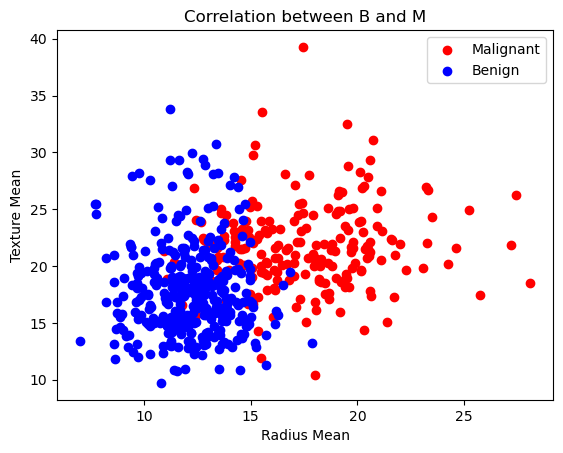

In [5]:
M = data[data.diagnosis == 'M']
B = data[data.diagnosis == 'B']

plt.title("Correlation between B and M")
plt.scatter(M.radius_mean, M.texture_mean, color='red', label='Malignant')
plt.scatter(B.radius_mean, B.texture_mean, color='blue', label='Benign')
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.legend()
plt.show()

In [6]:
data.diagnosis = [1 if each == 'M' else 0 for each in data.diagnosis]
data.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, x_test, y_train, y_test = train_test_split(data.drop(['diagnosis'], axis=1), data.diagnosis, test_size=0.2, random_state=42)

X_train_raw = np.clip(np.round(X_train.values), 0, None).astype(int)
x_test_raw = np.clip(np.round(x_test.values), 0, None).astype(int)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
x_test = sc.transform(x_test)


In [8]:
class NaiveBayesClassifier:
    def __init__(self, pdf = "Gaussian"):
        self._pdf = self._Gaussian_pdf if pdf == "Gaussian" else self._Multinomial_pdf

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        self._mean = np.zeros((n_classes, n_features), dtype = np.float64)
        self._var = np.zeros((n_classes, n_features), dtype = np.float64)
        self._priors = np.zeros(n_classes, dtype = np.float64)

        for idx, c in enumerate(self._classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis = 0)
            self._var[idx, :] = X_c.var(axis = 0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def _predict(self, x):
        posteriors = []

        for idx, c in enumerate(self._classes):
            prior = np.log(self._priors[idx])
            class_conditional = np.sum(np.log(self._pdf(idx, x) + 1e-300))
            posterior = prior + class_conditional
            posteriors.append(posterior)

        return self._classes[np.argmax(posteriors)]

    def _Gaussian_pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        var = self._var[class_idx] + 1e-9
        numerator = np.exp(- (x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def _Multinomial_pdf(self, class_idx, x):
        mean = self._mean[class_idx]
        log_prob = x * np.log(mean + 1e-9) - mean - np.array([math.lgamma(int(xi) + 1) for xi in x])
        return np.exp(log_prob)

    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    


In [9]:
gnb = NaiveBayesClassifier(pdf = "Gaussian")
mnb = NaiveBayesClassifier(pdf = "Multinomial")

gnb.fit(X_train, y_train)
mnb.fit(X_train_raw, y_train)

y_pred_gnb = gnb.predict(x_test)
y_pred_mnb = mnb.predict(x_test_raw)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print("Gaussian Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("F1 Score:", f1_score(y_test, y_pred_gnb))
print("Precision:", precision_score(y_test, y_pred_gnb))
print("Recall:", recall_score(y_test, y_pred_gnb))
print("\nMultinomial Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("F1 Score:", f1_score(y_test, y_pred_mnb))
print("Precision:", precision_score(y_test, y_pred_mnb))
print("Recall:", recall_score(y_test, y_pred_mnb))


Gaussian Naive Bayes:
Accuracy: 0.9649122807017544
F1 Score: 0.9523809523809523
Precision: 0.975609756097561
Recall: 0.9302325581395349

Multinomial Naive Bayes:
Accuracy: 0.9473684210526315
F1 Score: 0.925
Precision: 1.0
Recall: 0.8604651162790697


In [10]:
from sklearn.metrics import confusion_matrix
print("Gaussian NB - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gnb))
print(f"Predicted class distribution: {np.unique(y_pred_gnb, return_counts=True)}")
print("\nMultinomial NB - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_mnb))
print(f"Predicted class distribution: {np.unique(y_pred_mnb, return_counts=True)}")


Gaussian NB - Confusion Matrix:
[[70  1]
 [ 3 40]]
Predicted class distribution: (array([0, 1]), array([73, 41]))

Multinomial NB - Confusion Matrix:
[[71  0]
 [ 6 37]]
Predicted class distribution: (array([0, 1]), array([77, 37]))
